# The RGC cell clustering

Here we are clustering a bunch of RGC cells in the Retina of a mouse. The receptive fields are modeled as ellipses. First we will try to cluster them by being on/ and off and then by being big or small, and then by the eccentricity. Using K-means and/or agglomerative clustering.

Cluster based on time courses: For now we should Normalize the data using the so call z-test norm. This works best for K-mean. Or does it really??? To some degree we have to some sort of normalization, this is important bc I don't want the clustering to be based on the amplitude of the signal. I see previously cases were a single very large spike counted as its very own 1-member group. We need to avoid classification based on signal's strenght but rather the overall pattern. The I will do K-means on the area of each ellipse. And then followed by K-mean clustering on eccentricity. In all of these cases I am respecting the highest silhouette score value. We will see what happens.

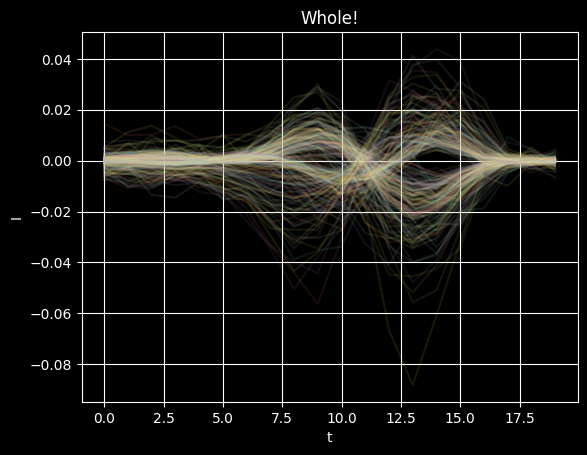

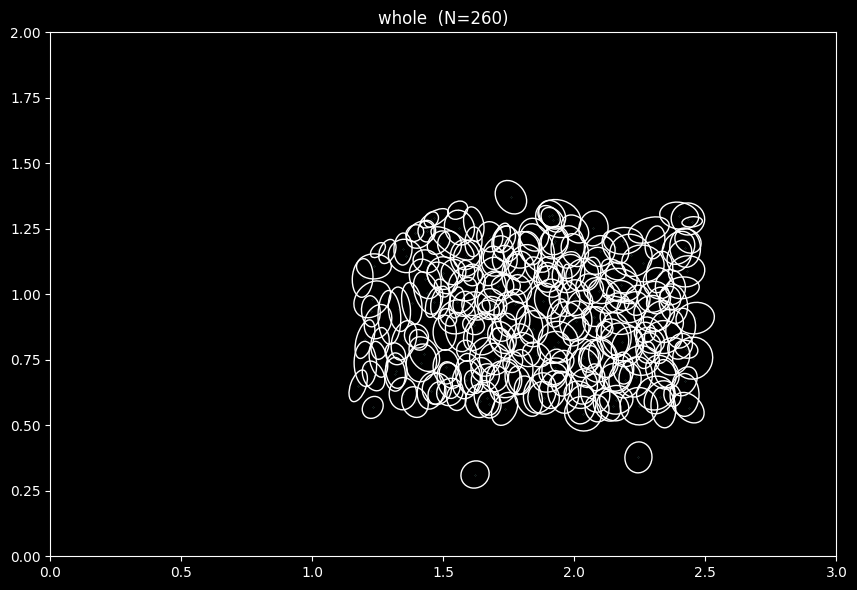

k=2  silhouette=0.691
k=3  silhouette=0.651
k=4  silhouette=0.549
k=5  silhouette=0.539
k=6  silhouette=0.537
k=7  silhouette=0.434
k=8  silhouette=0.387
k=9  silhouette=0.398
End of Silhouette test

Sil (whole -> on/off): 0.6914208076708209


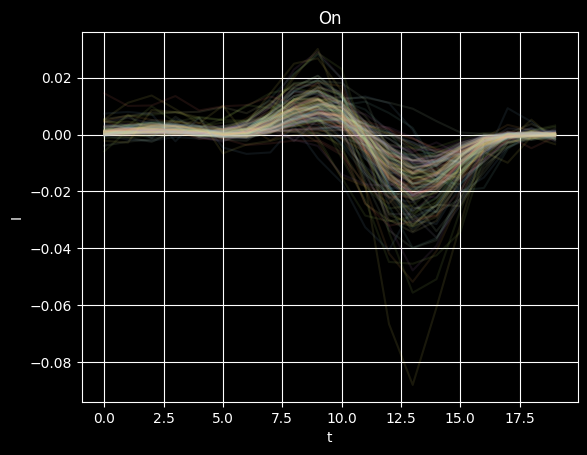

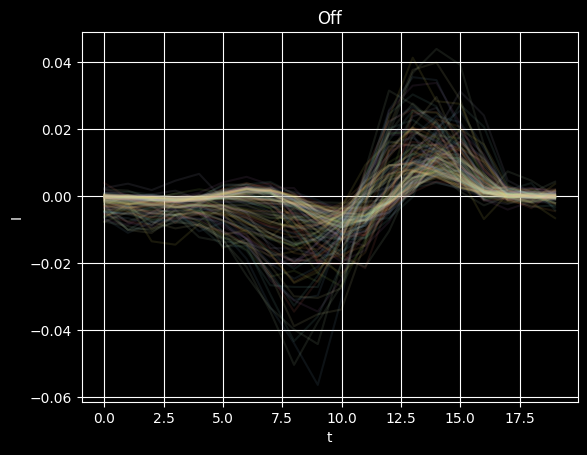

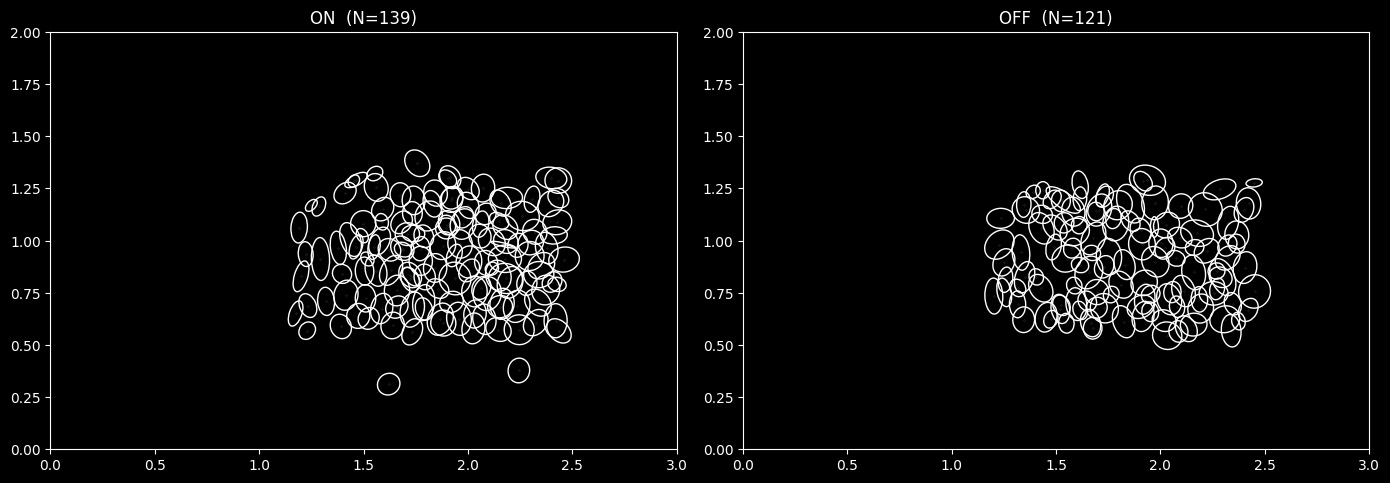

Optimum sil score for size clustering is as follows. I stop running the K-loop here for the sake of clarity:
Sil (on -> small/big): 0.5632113652555095
Sil (off -> small/big): 0.6501478654243706



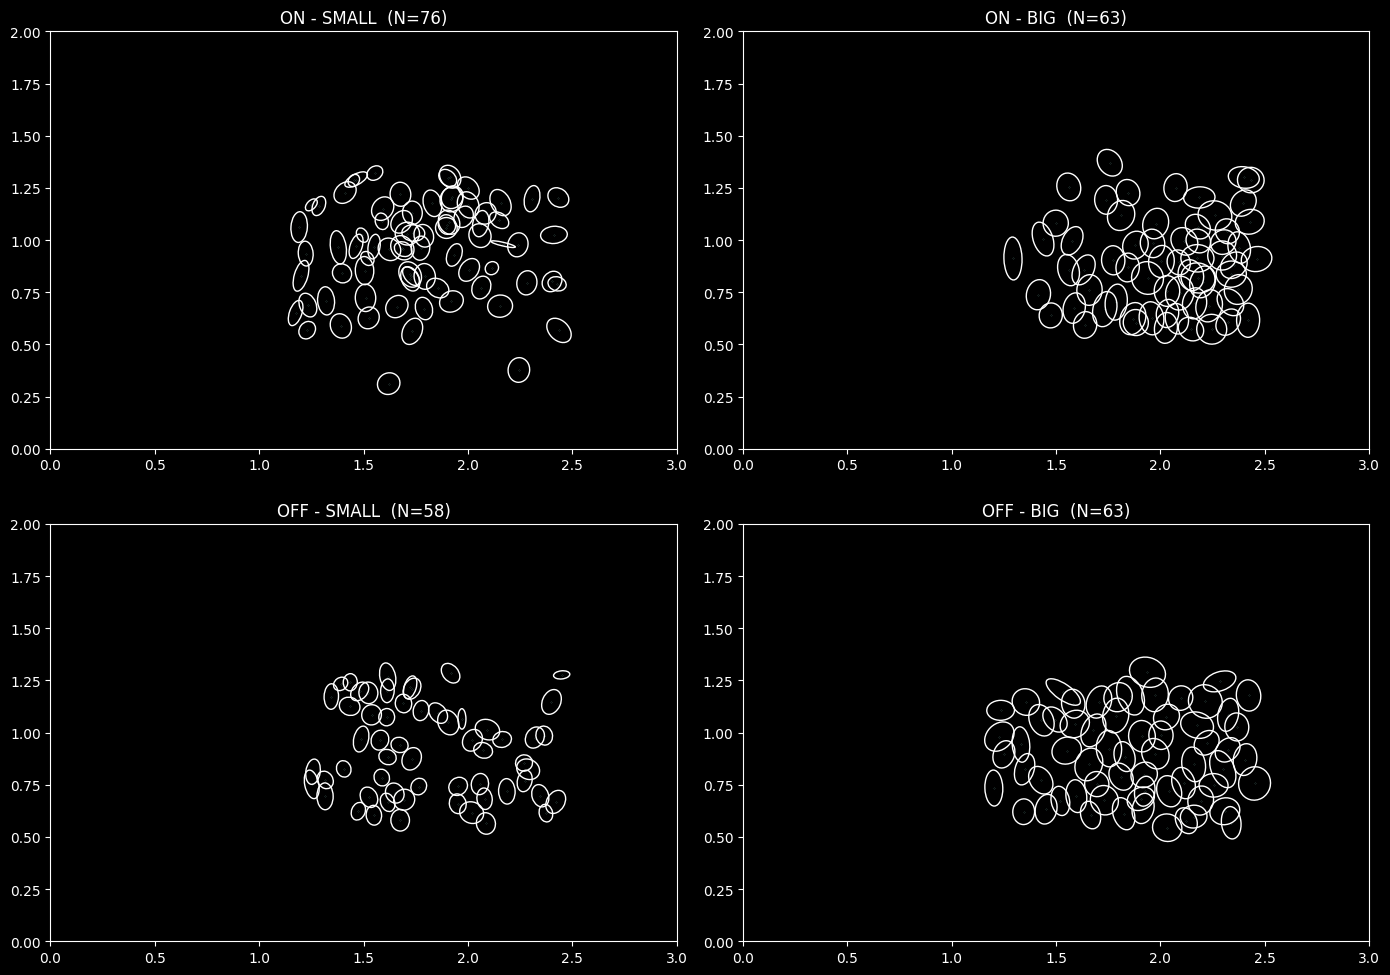

Optimum K-means (I stop running the K-loop for the sake of clarity):
Sil (ON - SMALL, k=10): 0.5945
Sil (ON - BIG, k=2): 0.5989
Sil (OFF - SMALL, k=3): 0.5588
Sil (OFF - BIG, k=12): 0.6093


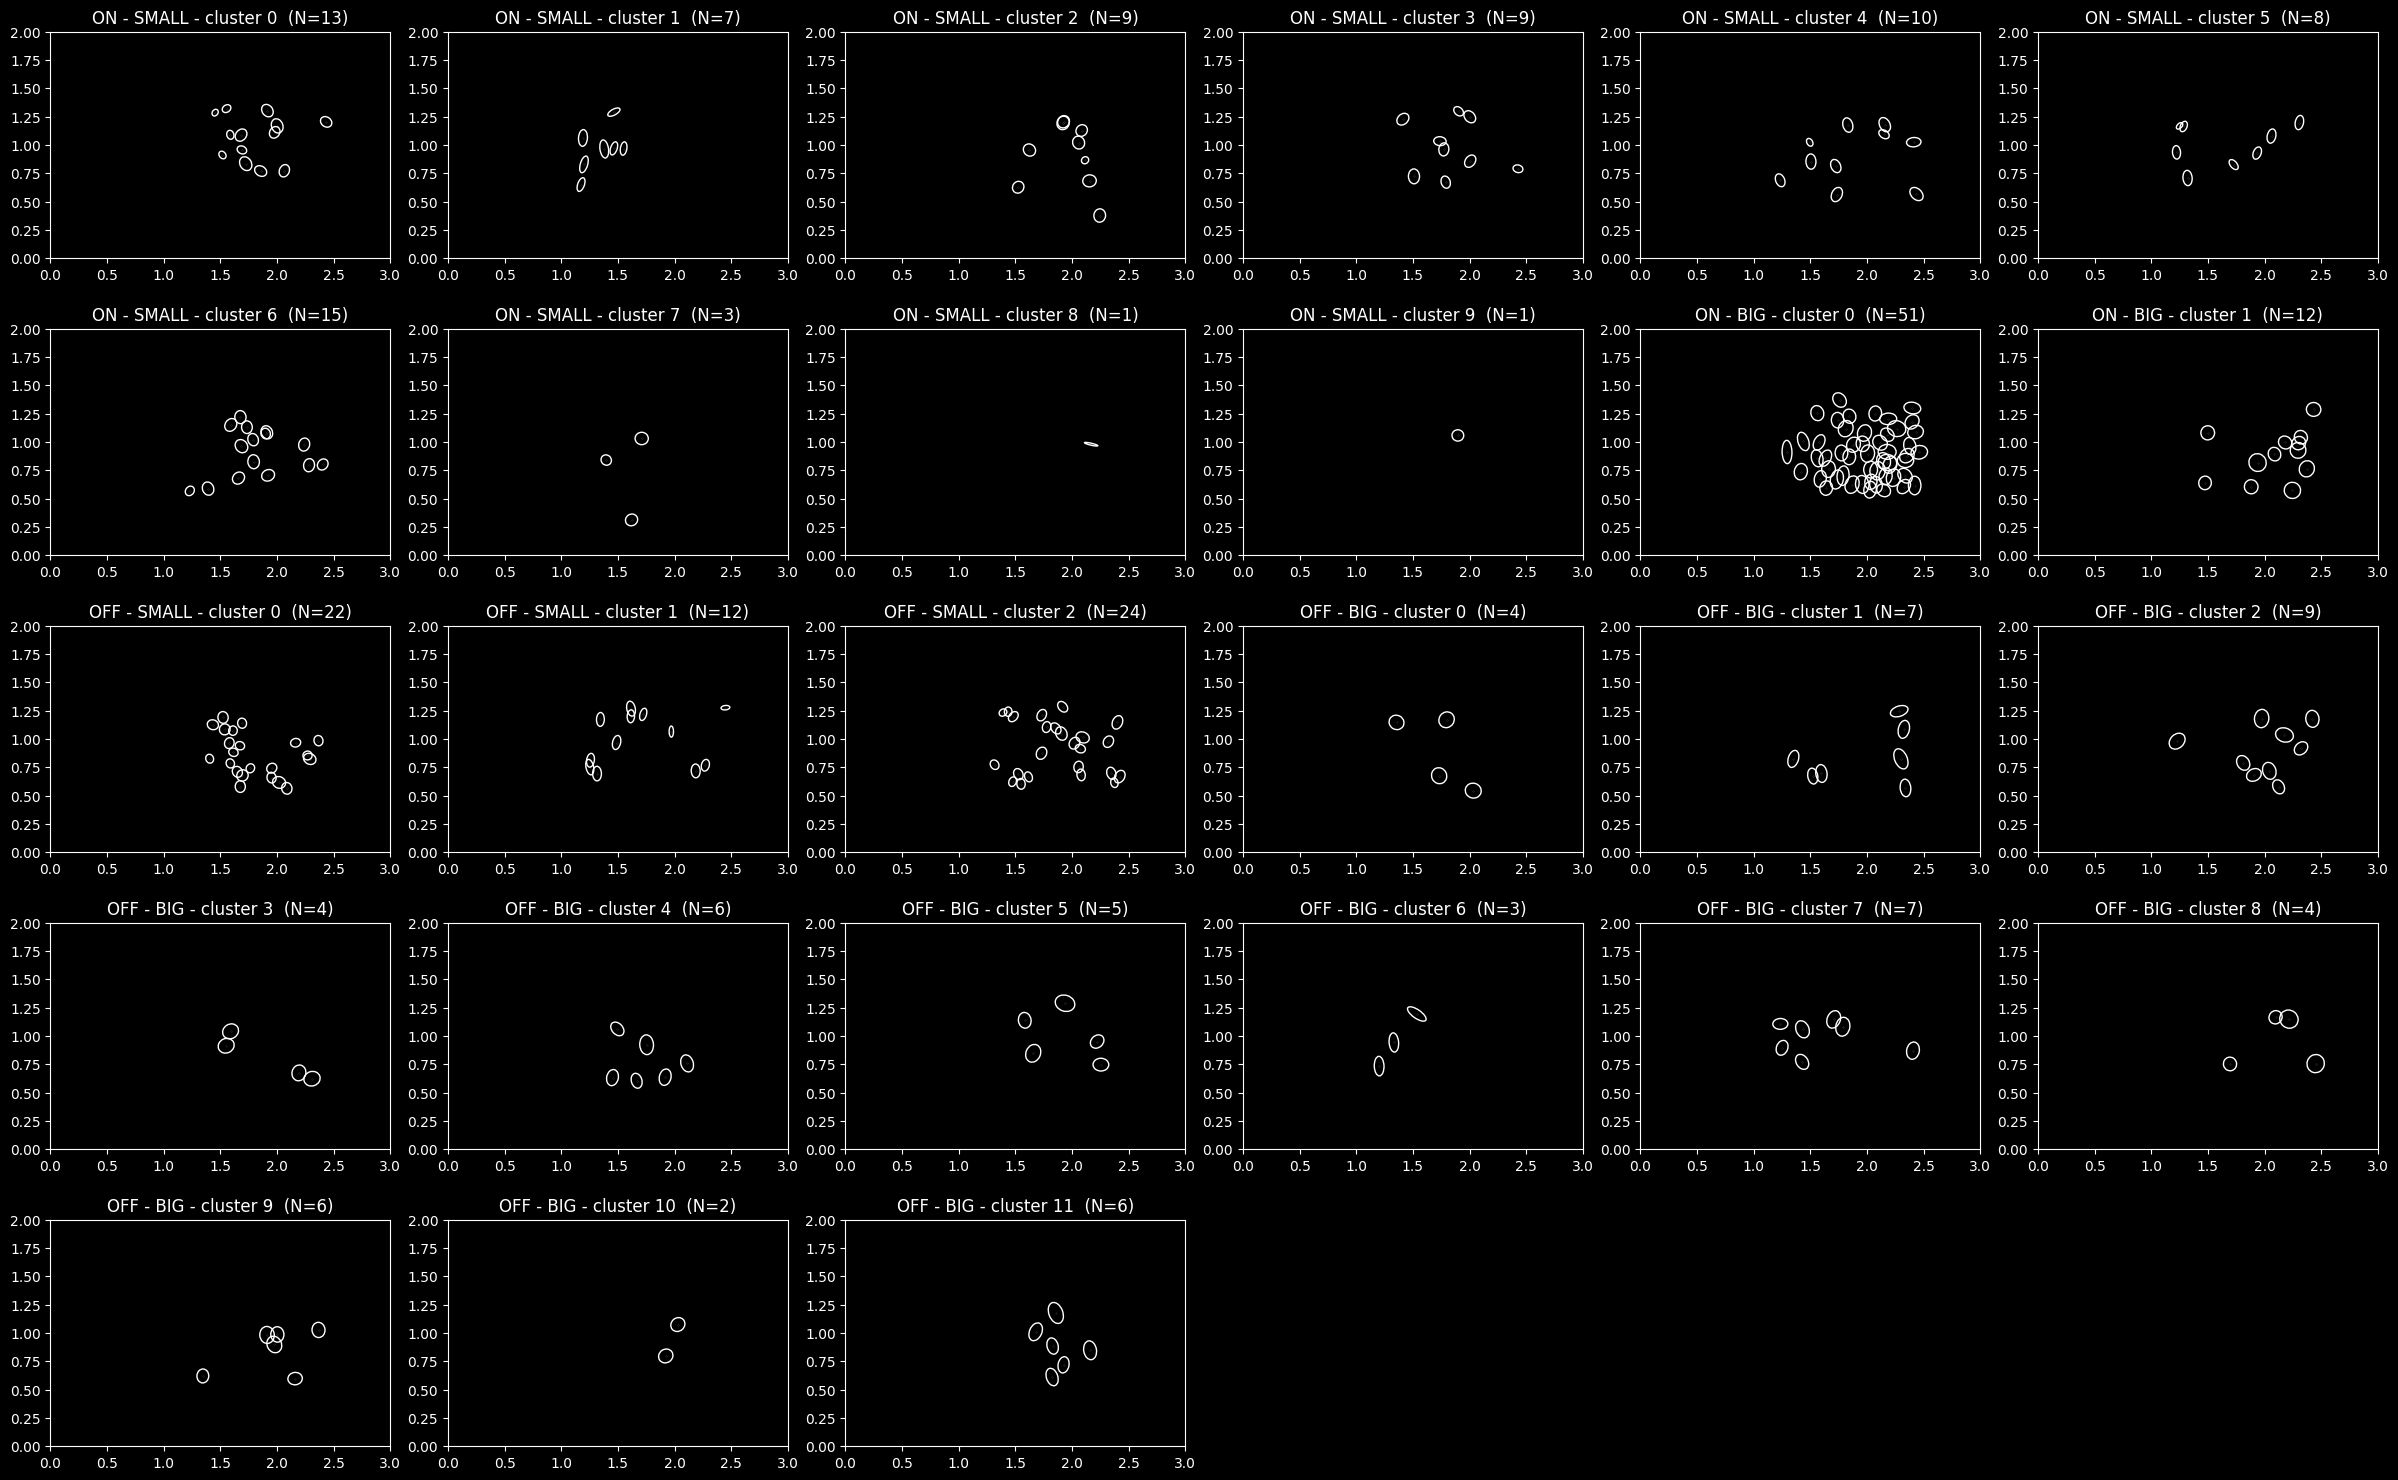

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#K-mean, with strictly respecting the sil score for each single clustering process.



# =========================
# Load + column accessors
# =========================
A = np.loadtxt("mod.txt")
ID, X, Y, SX, SY, TH = (A[:, i] for i in range(6))
TC = A[:, 6:].astype(float)

def zscore_rows(m, eps=1e-12):
    mu = m.mean(1, keepdims=True)
    sd = m.std(1, keepdims=True)
    return (m - mu) / (sd + eps)

def split(arr, k, lab):
    return [arr[lab == i] for i in range(k)]

def enforce_label0_smaller(values_1col, labels):
    return (1 - labels) if values_1col[labels == 0].mean() > values_1col[labels == 1].mean() else labels

# Plotting (with N in title)
def plot_groups(groups, nrows, ncols, conv=1000, escale=60, xlim=(0,3), ylim=(0,2), figsize=(14,10)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)

    for ax, (title, x, y, sx, sy, th) in zip(axes, groups):

        n = len(x)  # number of ellipses

        x, y = np.asarray(x)/conv, np.asarray(y)/conv
        sx, sy = np.asarray(sx)/conv, np.asarray(sy)/conv
        th = np.rad2deg(np.asarray(th))

        ax.scatter(x, y, s=0.01)

        for xi, yi, a, b, ang in zip(x, y, sx, sy, th):
            ax.add_patch(Ellipse((xi, yi), 2*a*escale, 2*b*escale,
                                 angle=-ang, fill=False, lw=1))

        ax.set(xlim=xlim, ylim=ylim, aspect="equal")
        ax.set_title(f"{title}  (N={n})")

    # Hide unused subplots
    for j in range(len(groups), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

def plotTimeCourse(timecourses, Ttitle=""):

    # print("Timecourse shape:", timecourses.shape)
    for tc in timecourses:
        plt.plot(tc, alpha=0.1)  # alpha makes overlap easier to see

    plt.xlabel("t")
    plt.ylabel("I")
    plt.title(Ttitle)
    plt.grid(True)
    plt.show()

rn = 220


def k_tester(arr, kmax=10):
    #arr = np.asarray(arr).reshape(-1,1)  # okay, this is essential. because kmean needs a multidim array, and this is one dim array. this fixes the issue per error's suggestion
    for k in range(2, kmax):
        km = KMeans(n_clusters=k, n_init=100, random_state=rn)
        labels = km.fit_predict(arr)

        sil = silhouette_score(arr, labels)

        print(f"k={k}  silhouette={sil:.3f}")
    print("End of Silhouette test\n")


# =========================
# 1) ON/OFF clustering
# =========================




tc_n = zscore_rows(TC)
k2 = 2

plotTimeCourse(timecourses=TC,Ttitle="Whole!")

plot_groups([("whole",X, Y, SX, SY, TH )],nrows=1,ncols=1,figsize=(14,6))




k_tester(tc_n)

lab_onoff = KMeans(n_clusters=k2, n_init=100, random_state=rn).fit_predict(tc_n)
print("Sil (whole -> on/off):", silhouette_score(tc_n, lab_onoff))

(tc_on, tc_off), (x_on, x_off), (y_on, y_off), \
(sx_on, sx_off), (sy_on, sy_off), (th_on, th_off), (id_on, id_off) = \
    (split(v, k2, lab_onoff) for v in (TC, X, Y, SX, SY, TH, ID))

plotTimeCourse(tc_on, Ttitle="On")
plotTimeCourse(tc_off, Ttitle="Off")


plot_groups(
    [("ON", x_on, y_on, sx_on, sy_on, th_on),
     ("OFF", x_off, y_off, sx_off, sy_off, th_off)],
    1, 2, figsize=(14, 6)
)


# =========================
# 2) Area clustering
# =========================
area_on  = (np.pi * np.asarray(sx_on)  * np.asarray(sy_on)).reshape(-1,1)
area_off = (np.pi * np.asarray(sx_off) * np.asarray(sy_off)).reshape(-1,1)

lab_area_on  = KMeans(2, n_init=100, random_state=rn).fit_predict(area_on)
lab_area_off = KMeans(2, n_init=100, random_state=rn).fit_predict(area_off)

lab_area_on  = enforce_label0_smaller(area_on,  lab_area_on)
lab_area_off = enforce_label0_smaller(area_off, lab_area_off)

(on_s, on_b) = split(np.arange(len(x_on)), 2, lab_area_on)
(off_s, off_b) = split(np.arange(len(x_off)), 2, lab_area_off)

print("Optimum sil score for size clustering is as follows. I stop running the K-loop here for the sake of clarity:")
print("Sil (on -> small/big):", silhouette_score(area_on, lab_area_on))
print("Sil (off -> small/big):", silhouette_score(area_off, lab_area_off))
print()


def take(idx, *vals):
    return [np.asarray(v)[idx] for v in vals]

tc_on_s, x_on_s, y_on_s, sx_on_s, sy_on_s, th_on_s, id_on_s = take(on_s, TC[lab_onoff==0], x_on, y_on, sx_on, sy_on, th_on, id_on)
tc_on_b, x_on_b, y_on_b, sx_on_b, sy_on_b, th_on_b, id_on_b = take(on_b, TC[lab_onoff==0], x_on, y_on, sx_on, sy_on, th_on, id_on)

tc_off_s, x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s, id_off_s = take(off_s, TC[lab_onoff==1], x_off, y_off, sx_off, sy_off, th_off, id_off)
tc_off_b, x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b, id_off_b = take(off_b, TC[lab_onoff==1], x_off, y_off, sx_off, sy_off, th_off, id_off)

plot_groups(
    [("ON - SMALL",  x_on_s,  y_on_s,  sx_on_s,  sy_on_s,  th_on_s),
     ("ON - BIG",    x_on_b,  y_on_b,  sx_on_b,  sy_on_b,  th_on_b),
     ("OFF - SMALL", x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s),
     ("OFF - BIG",   x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b)],
    2, 2, figsize=(14, 10)
)

# ==========================================================================
# 3) Eccentricity clustering with custom k for each subgroup (modified part)
# ==========================================================================
def ecc(sx, sy):
    mn, mx = np.minimum(sx, sy), np.maximum(sx, sy)
    return np.sqrt(1 - (mn**2)/(mx**2)).reshape(-1,1)

# Helper to perform clustering and collect groups
def cluster_ecc_and_collect(name, x, y, sx, sy, th, ids, k):
    """
    Perform k-means clustering on eccentricity with k clusters.
    Returns a list of (title, x, y, sx, sy, th) for each cluster.
    """
    e = ecc(np.asarray(sx), np.asarray(sy))
    kmeans = KMeans(n_clusters=k, n_init=100, random_state=rn)
    labels = kmeans.fit_predict(e)
    sil = silhouette_score(e, labels)
    print(f"Sil ({name}, k={k}): {sil:.4f}")

    groups = []
    for i in range(k):
        mask = labels == i
        title = f"{name} - cluster {i}"
        groups.append((
            title,
            np.asarray(x)[mask],
            np.asarray(y)[mask],
            np.asarray(sx)[mask],
            np.asarray(sy)[mask],
            np.asarray(th)[mask]
        ))
    return groups

# Collect all groups
all_groups = []

print("Optimum K-means (I stop running the K-loop for the sake of clarity):")

# ON - SMALL (k=10)
all_groups.extend(cluster_ecc_and_collect("ON - SMALL", x_on_s, y_on_s, sx_on_s, sy_on_s, th_on_s, id_on_s, k=10))

# ON - BIG (k=2)
all_groups.extend(cluster_ecc_and_collect("ON - BIG", x_on_b, y_on_b, sx_on_b, sy_on_b, th_on_b, id_on_b, k=2))

# OFF - SMALL (k=3)
all_groups.extend(cluster_ecc_and_collect("OFF - SMALL", x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s, id_off_s, k=3))

# OFF - BIG (k=12)
all_groups.extend(cluster_ecc_and_collect("OFF - BIG", x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b, id_off_b, k=12))

# Determine grid size for plotting
n_groups = len(all_groups)
ncols = int(np.ceil(np.sqrt(n_groups)))
nrows = int(np.ceil(n_groups / ncols))
figsize = (ncols * 4, nrows * 3)  # scale figure size

plot_groups(all_groups, nrows, ncols, figsize=figsize)

This last clustering, was definitely an over-clustering. There is no group of a single cell. Biologically it is not feasible.
Let us do this a bit differently. Now with agglomerative clustering for the eccentricity part. The number of clusters is being controlled by a "threshold " value. I can later on go deeper in the dendrogram of this hierarchical  clustering. This is something to be done later. The code and results are as follows (code almost the same upto the eccentricity clustering)

Sil (whole -> on/off): 0.6914208076708209


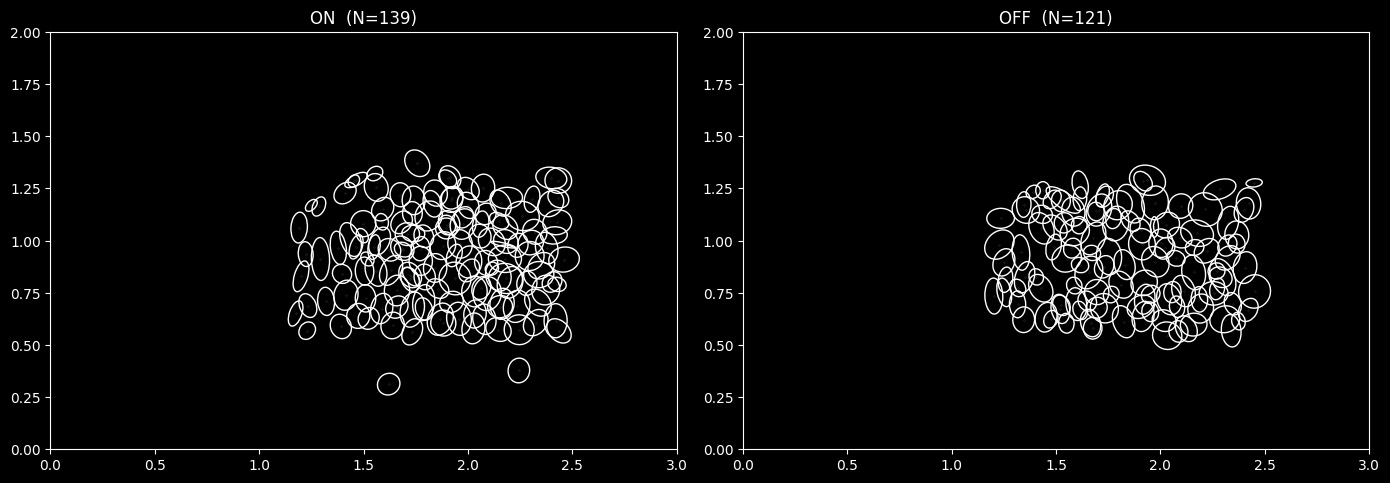

Sil (on --> small/big) 0.5632113652555095
Sil (off --> small/big) 0.6501478654243706


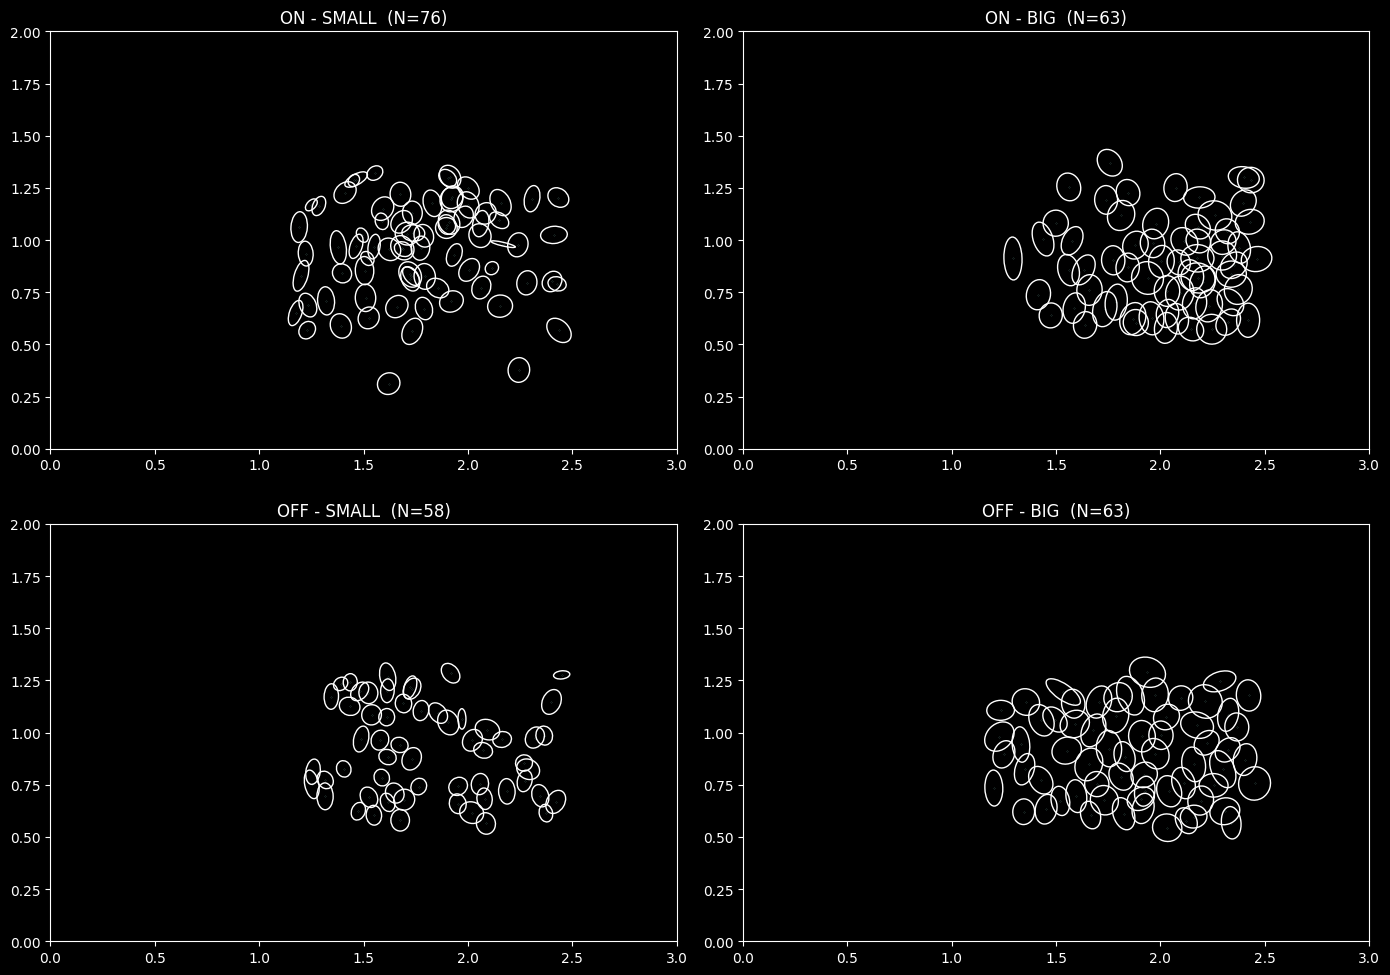

Sil (ON - SMALL, threshold=0.28): not computed (clusters=1, some size 1)
Sil (ON - BIG, threshold=0.28): 0.5989  (found 2 clusters)
Sil (OFF - SMALL, threshold=0.28): 0.4986  (found 2 clusters)
Sil (OFF - BIG, threshold=0.28): not computed (clusters=1, some size 1)


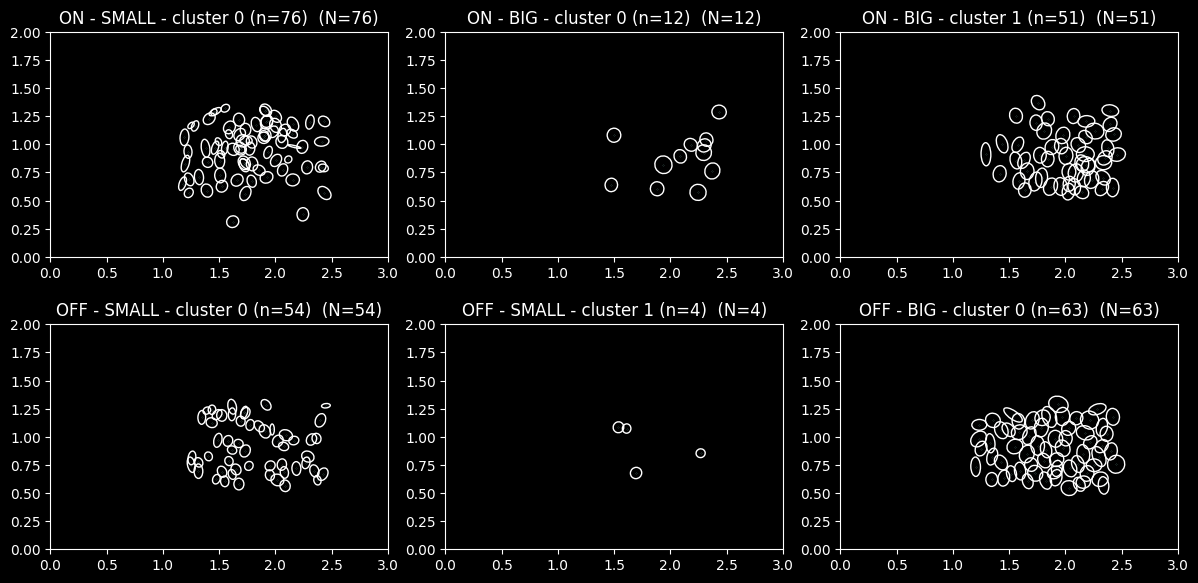

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score


#aggmolorative clustering only for eccentricity. the rest prior to eccentricity was K-means


# =========================
# Load + column accessors
# =========================
A = np.loadtxt("mod.txt")
ID, X, Y, SX, SY, TH = (A[:, i] for i in range(6))
TC = A[:, 6:].astype(float)


def zscore_rows(m, eps=1e-12):
    mu = m.mean(1, keepdims=True)
    sd = m.std(1, keepdims=True)
    return (m - mu) / (sd + eps)


def split(arr, k, lab):
    return [arr[lab == i] for i in range(k)]


def enforce_label0_smaller(values_1col, labels):
    return (1 - labels) if values_1col[labels == 0].mean() > values_1col[labels == 1].mean() else labels


# =========================
# Plotting (with N in title)
# =========================
def plot_groups(groups, nrows, ncols, conv=1000, escale=60, xlim=(0, 3), ylim=(0, 2), figsize=(14, 10)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)

    for ax, (title, x, y, sx, sy, th) in zip(axes, groups):

        n = len(x)  # number of ellipses

        x, y = np.asarray(x) / conv, np.asarray(y) / conv
        sx, sy = np.asarray(sx) / conv, np.asarray(sy) / conv
        th = np.rad2deg(np.asarray(th))

        ax.scatter(x, y, s=0.01)

        for xi, yi, a, b, ang in zip(x, y, sx, sy, th):
            ax.add_patch(Ellipse((xi, yi), 2 * a * escale, 2 * b * escale,
                                 angle=-ang, fill=False, lw=1))

        ax.set(xlim=xlim, ylim=ylim, aspect="equal")
        ax.set_title(f"{title}  (N={n})")

    # Hide unused subplots
    for j in range(len(groups), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


# =========================
# 1) ON/OFF clustering
# =========================
tc_n = zscore_rows(TC)
k2 = 2
lab_onoff = KMeans(n_clusters=k2, n_init=100, random_state=22).fit_predict(tc_n)
print("Sil (whole -> on/off):", silhouette_score(tc_n, lab_onoff))
print("===============================================================================")

(tc_on, tc_off), (x_on, x_off), (y_on, y_off), \
    (sx_on, sx_off), (sy_on, sy_off), (th_on, th_off), (id_on, id_off) = \
    (split(v, k2, lab_onoff) for v in (TC, X, Y, SX, SY, TH, ID))

plot_groups(
    [("ON", x_on, y_on, sx_on, sy_on, th_on),
     ("OFF", x_off, y_off, sx_off, sy_off, th_off)],
    1, 2, figsize=(14, 6)
)

# =========================
# 2) Area clustering
# =========================
area_on = (np.pi * np.asarray(sx_on) * np.asarray(sy_on)).reshape(-1, 1)
area_off = (np.pi * np.asarray(sx_off) * np.asarray(sy_off)).reshape(-1, 1)

lab_area_on = KMeans(2, n_init=100, random_state=22).fit_predict(area_on)
lab_area_off = KMeans(2, n_init=100, random_state=22).fit_predict(area_off)


lab_area_on = enforce_label0_smaller(area_on, lab_area_on)
lab_area_off = enforce_label0_smaller(area_off, lab_area_off)

print("Sil (on --> small/big)", silhouette_score(area_on, lab_area_on))
print("Sil (off --> small/big)", silhouette_score(area_off, lab_area_off))
print("===============================================================================")


(on_s, on_b) = split(np.arange(len(x_on)), 2, lab_area_on)
(off_s, off_b) = split(np.arange(len(x_off)), 2, lab_area_off)


def take(idx, *vals):
    return [np.asarray(v)[idx] for v in vals]


tc_on_s, x_on_s, y_on_s, sx_on_s, sy_on_s, th_on_s, id_on_s = take(on_s, TC[lab_onoff == 0], x_on, y_on, sx_on, sy_on,
                                                                   th_on, id_on)
tc_on_b, x_on_b, y_on_b, sx_on_b, sy_on_b, th_on_b, id_on_b = take(on_b, TC[lab_onoff == 0], x_on, y_on, sx_on, sy_on,
                                                                   th_on, id_on)

tc_off_s, x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s, id_off_s = take(off_s, TC[lab_onoff == 1], x_off, y_off,
                                                                          sx_off, sy_off, th_off, id_off)
tc_off_b, x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b, id_off_b = take(off_b, TC[lab_onoff == 1], x_off, y_off,
                                                                          sx_off, sy_off, th_off, id_off)

plot_groups(
    [("ON - SMALL", x_on_s, y_on_s, sx_on_s, sy_on_s, th_on_s),
     ("ON - BIG", x_on_b, y_on_b, sx_on_b, sy_on_b, th_on_b),
     ("OFF - SMALL", x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s),
     ("OFF - BIG", x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b)],
    2, 2, figsize=(14, 10)
)


# ==========================================================================
# 3) Eccentricity clustering with agglomerative clustering (no fixed k)
# ==========================================================================
def ecc(sx, sy):
    mn, mx = np.minimum(sx, sy), np.maximum(sx, sy)
    return np.sqrt(1 - (mn ** 2) / (mx ** 2)).reshape(-1, 1)

# Helper to perform agglomerative clustering with distance threshold
def cluster_ecc_agglomerative(name, x, y, sx, sy, th, ids, distance_threshold=0.1):
    """
    Perform agglomerative clustering on eccentricity with a distance threshold.
    The number of clusters is automatically determined.
    Returns a list of (title, x, y, sx, sy, th) for each cluster.
    """

    e = ecc(np.asarray(sx), np.asarray(sy))

    # Use AgglomerativeClustering with distance threshold
    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=distance_threshold,
        compute_full_tree=True,
        compute_distances=True,
        linkage = 'average',
    )
    labels = clustering.fit_predict(e)
    n_clusters = len(set(labels))

    # Silhouette score (only if valid)
    if n_clusters >= 2 and all(np.sum(labels == i) > 1 for i in range(n_clusters)):
        sil = silhouette_score(e, labels)

        print(f"Sil ({name}, threshold={distance_threshold}): {sil:.4f}  (found {n_clusters} clusters)")
    else:
        print(f"Sil ({name}, threshold={distance_threshold}): not computed (clusters={n_clusters}, some size 1)")

    groups = []
    for i in range(n_clusters):
        mask = labels == i
        title = f"{name} - cluster {i} (n={np.sum(mask)})"
        groups.append((
            title,
            np.asarray(x)[mask],
            np.asarray(y)[mask],
            np.asarray(sx)[mask],
            np.asarray(sy)[mask],
            np.asarray(th)[mask]
        ))
    return groups


# Collect all groups
all_groups = []


# Choose a distance threshold for eccentricity (values are in [0,1])
threshold = 0.28  # adjust as needed. Higher coarser, smaller finer grouping.0.25 0.3

# ON - SMALL
all_groups.extend(cluster_ecc_agglomerative("ON - SMALL", x_on_s, y_on_s, sx_on_s, sy_on_s, th_on_s, id_on_s,
                                            distance_threshold=threshold))

# ON - BIG
all_groups.extend(cluster_ecc_agglomerative("ON - BIG", x_on_b, y_on_b, sx_on_b, sy_on_b, th_on_b, id_on_b,
                                            distance_threshold=threshold))

# OFF - SMALL
all_groups.extend(cluster_ecc_agglomerative("OFF - SMALL", x_off_s, y_off_s, sx_off_s, sy_off_s, th_off_s, id_off_s,
                                            distance_threshold=threshold))

# OFF - BIG
all_groups.extend(cluster_ecc_agglomerative("OFF - BIG", x_off_b, y_off_b, sx_off_b, sy_off_b, th_off_b, id_off_b,
                                            distance_threshold=threshold))

# Determine grid size for plotting
n_groups = len(all_groups)
ncols = int(np.ceil(np.sqrt(n_groups)))
nrows = int(np.ceil(n_groups / ncols))
figsize = (ncols * 4, nrows * 3)  # scale figure size

plot_groups(all_groups, nrows, ncols, figsize=figsize)

The Off_small_cluster0 and Off_big_cluster0 seems to be in very good agreement with the establisher classifications. The rest not so much!

# The END ^^^

## Attachments:

It will be interesting to see how K-mean clustering works if we cluster based on the on/off --> size of major axis --> size of minor axis  (K is set to being equal to 2 for the last stage clustering. This is not respecting the silhouette score).

Sil (whole -> on/off): 0.6914208076708209


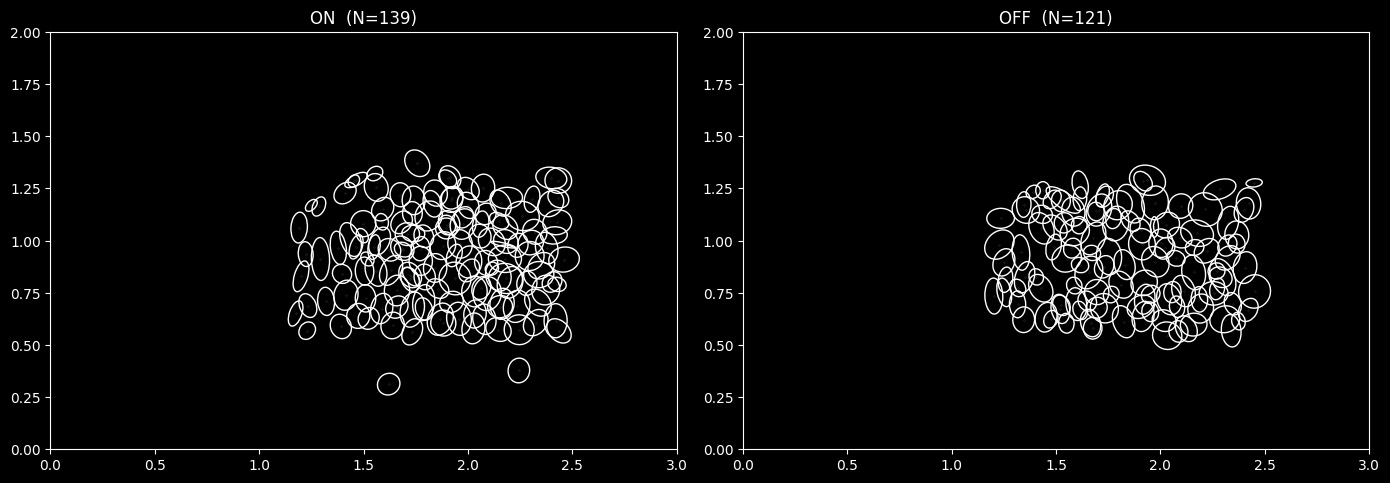

Sil (ON -> sx small/big):  0.5526398674239462
Sil (OFF -> sx small/big):  0.5851099277511086


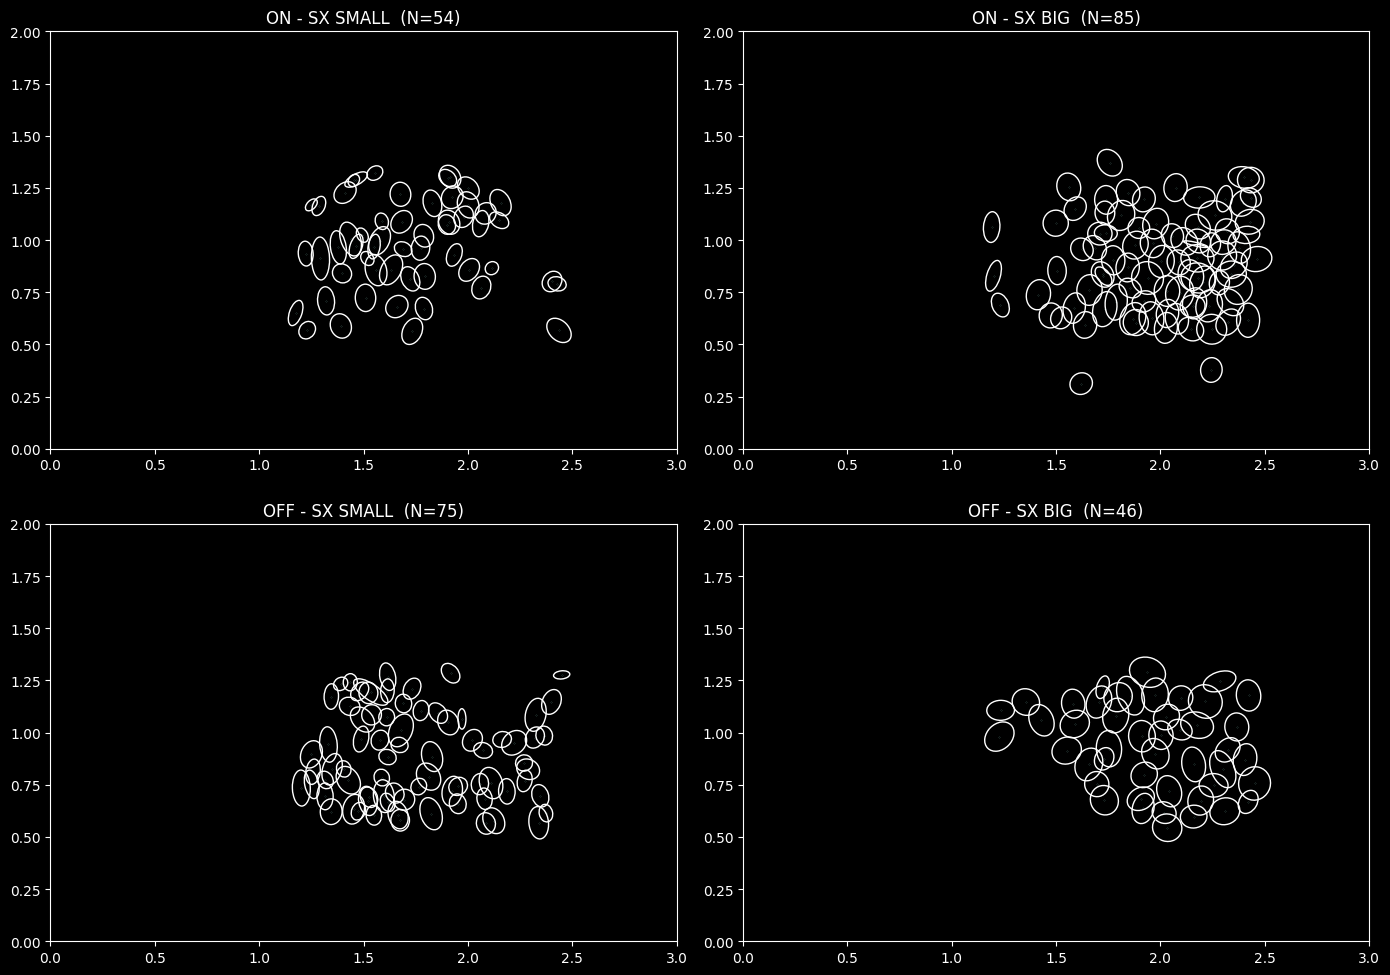

Sil (ON-SXsmall -> sy small/big): 0.616268619742601
Sil (ON-SXbig -> sy small/big): 0.5604076460089351
Sil (OFF-SXsmall -> sy small/big): 0.6346607066259851
Sil (OFF-SXbig -> sy small/big): 0.5726217000261744


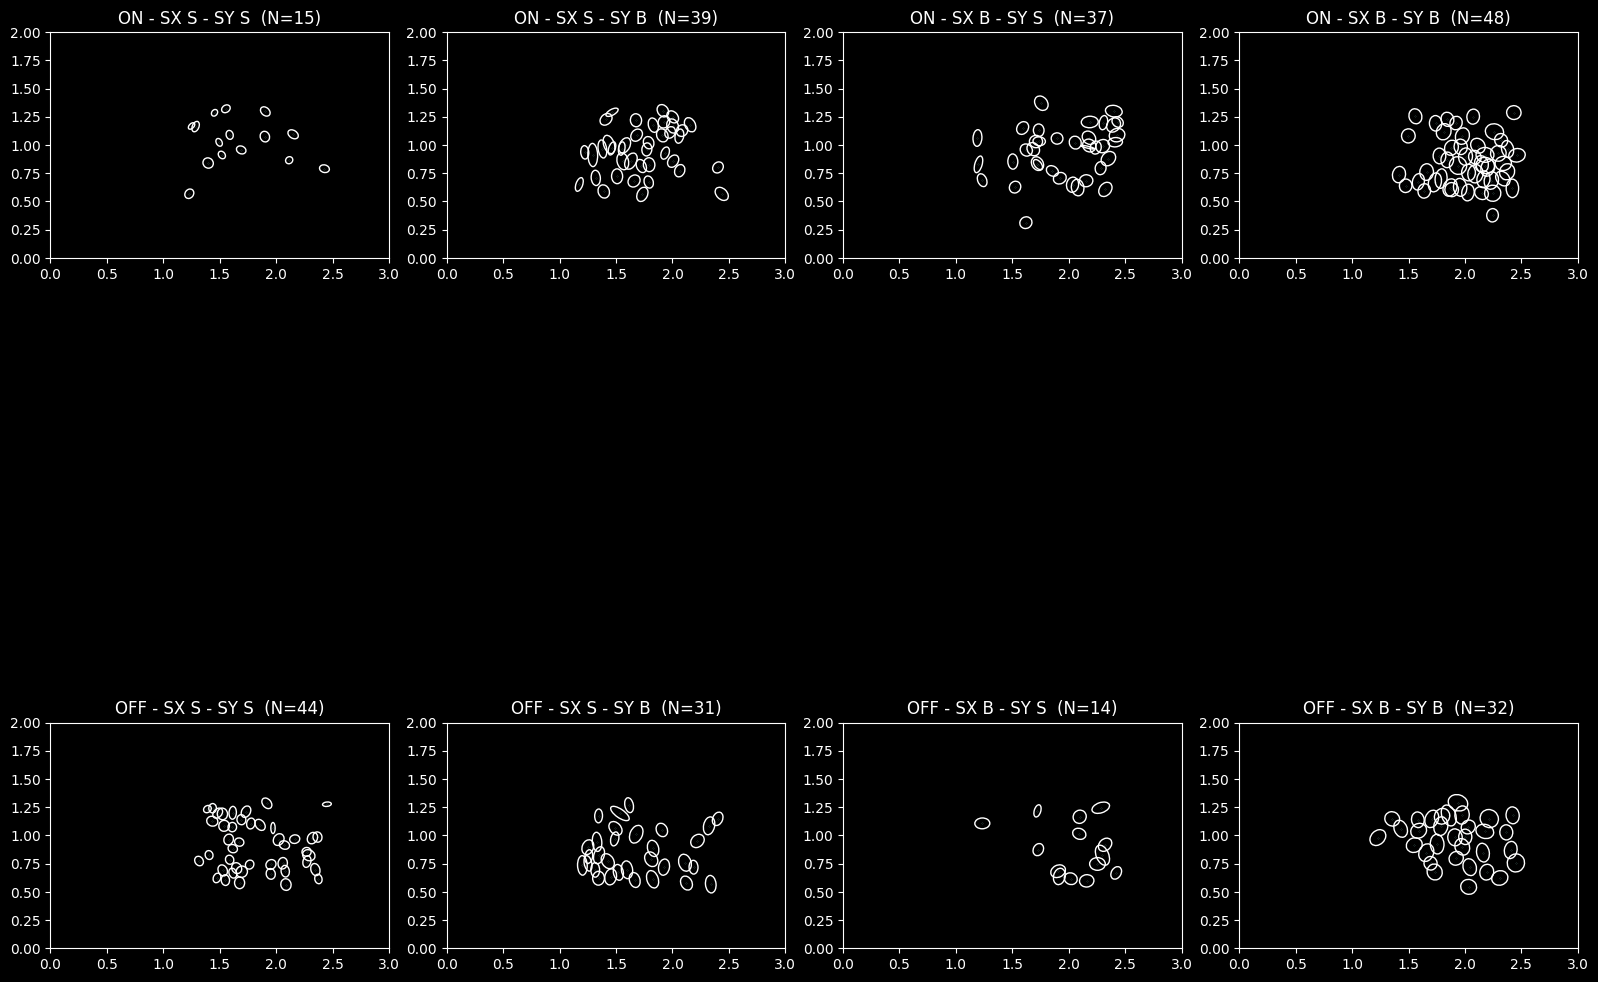

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Clustering based on size of minor and major axis


A = np.loadtxt("mod.txt")
ID, X, Y, SX, SY, TH = (A[:, i] for i in range(6))
TC = A[:, 6:].astype(float)

def zscore_rows(m, eps=1e-12):
    return (m - m.mean(1, keepdims=True)) / (m.std(1, keepdims=True) + eps)

def split(arr, k, lab):
    return [arr[lab == i] for i in range(k)]

def enforce_label0_smaller(values_1col, labels):
    return (1 - labels) if values_1col[labels == 0].mean() > values_1col[labels == 1].mean() else labels

def k2_labels(values_1col):
    lab = KMeans(2, n_init=100, random_state=22).fit_predict(values_1col)
    return enforce_label0_smaller(values_1col, lab)

def plot_groups(groups, nrows, ncols, conv=1000, escale=60, xlim=(0,3), ylim=(0,2), figsize=(14,10)):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.ravel(axes)
    for ax, (title, x, y, sx, sy, th) in zip(axes, groups):
        n = len(x)
        x, y = np.asarray(x)/conv, np.asarray(y)/conv
        sx, sy = np.asarray(sx)/conv, np.asarray(sy)/conv
        th = np.rad2deg(np.asarray(th))
        ax.scatter(x, y, s=0.01)
        for xi, yi, a, b, ang in zip(x, y, sx, sy, th):
            ax.add_patch(Ellipse((xi, yi), 2*a*escale, 2*b*escale, angle=-ang, fill=False, lw=1))
        ax.set(xlim=xlim, ylim=ylim, aspect="equal")
        ax.set_title(f"{title}  (N={n})")
    plt.tight_layout()
    plt.show()

# =========================
# 1) ON/OFF by timecourse
# =========================
tc_n = zscore_rows(TC)
lab_onoff = KMeans(2, n_init=100, random_state=22).fit_predict(tc_n)
print("Sil (whole -> on/off):", silhouette_score(tc_n, lab_onoff))

(tc_on, tc_off), (x_on, x_off), (y_on, y_off), (sx_on, sx_off), (sy_on, sy_off), (th_on, th_off), (id_on, id_off) = \
    (split(v, 2, lab_onoff) for v in (TC, X, Y, SX, SY, TH, ID))

plot_groups([("ON", x_on, y_on, sx_on, sy_on, th_on),
             ("OFF", x_off, y_off, sx_off, sy_off, th_off)],
            1, 2, figsize=(14, 6))

# =========================
# 2) SX within ON/OFF
# =========================
sx_on_1  = np.asarray(sx_on).reshape(-1, 1)
sx_off_1 = np.asarray(sx_off).reshape(-1, 1)

lab_sx_on  = k2_labels(sx_on_1)
lab_sx_off = k2_labels(sx_off_1)

print("Sil (ON -> sx small/big): ",  silhouette_score(sx_on_1,  lab_sx_on))
print("Sil (OFF -> sx small/big): ", silhouette_score(sx_off_1, lab_sx_off))

(tc_on_sxS, tc_on_sxB), (x_on_sxS, x_on_sxB), (y_on_sxS, y_on_sxB), \
(sx_on_sxS, sx_on_sxB), (sy_on_sxS, sy_on_sxB), (th_on_sxS, th_on_sxB), (id_on_sxS, id_on_sxB) = \
    (split(v, 2, lab_sx_on) for v in (tc_on, x_on, y_on, sx_on, sy_on, th_on, id_on))

(tc_off_sxS, tc_off_sxB), (x_off_sxS, x_off_sxB), (y_off_sxS, y_off_sxB), \
(sx_off_sxS, sx_off_sxB), (sy_off_sxS, sy_off_sxB), (th_off_sxS, th_off_sxB), (id_off_sxS, id_off_sxB) = \
    (split(v, 2, lab_sx_off) for v in (tc_off, x_off, y_off, sx_off, sy_off, th_off, id_off))

plot_groups(
    [("ON - SX SMALL",  x_on_sxS,  y_on_sxS,  sx_on_sxS,  sy_on_sxS,  th_on_sxS),
     ("ON - SX BIG",    x_on_sxB,  y_on_sxB,  sx_on_sxB,  sy_on_sxB,  th_on_sxB),
     ("OFF - SX SMALL", x_off_sxS, y_off_sxS, sx_off_sxS, sy_off_sxS, th_off_sxS),
     ("OFF - SX BIG",   x_off_sxB, y_off_sxB, sx_off_sxB, sy_off_sxB, th_off_sxB)],
    2, 2, figsize=(14, 10)
)

# =========================
# 3) SY within each (ON/OFF x SX)
# =========================
def sy_split(name, tc, x, y, sx, sy, th, ids):
    sy1 = np.asarray(sy).reshape(-1, 1)
    lab = k2_labels(sy1)
    print(f"Sil ({name} -> sy small/big):", silhouette_score(sy1, lab))
    parts = [split(v, 2, lab) for v in (tc, x, y, sx, sy, th, ids)]
    return [(p[0], p[1]) for p in parts]  # each is (sySmall, syBig)

(on_sxS_syS, on_sxS_syB), (x_on_sxS_syS, x_on_sxS_syB), (y_on_sxS_syS, y_on_sxS_syB), \
(sx_on_sxS_syS, sx_on_sxS_syB), (sy_on_sxS_syS, sy_on_sxS_syB), (th_on_sxS_syS, th_on_sxS_syB), _ = \
    sy_split("ON-SXsmall", tc_on_sxS, x_on_sxS, y_on_sxS, sx_on_sxS, sy_on_sxS, th_on_sxS, id_on_sxS)

(on_sxB_syS, on_sxB_syB), (x_on_sxB_syS, x_on_sxB_syB), (y_on_sxB_syS, y_on_sxB_syB), \
(sx_on_sxB_syS, sx_on_sxB_syB), (sy_on_sxB_syS, sy_on_sxB_syB), (th_on_sxB_syS, th_on_sxB_syB), _ = \
    sy_split("ON-SXbig", tc_on_sxB, x_on_sxB, y_on_sxB, sx_on_sxB, sy_on_sxB, th_on_sxB, id_on_sxB)

(off_sxS_syS, off_sxS_syB), (x_off_sxS_syS, x_off_sxS_syB), (y_off_sxS_syS, y_off_sxS_syB), \
(sx_off_sxS_syS, sx_off_sxS_syB), (sy_off_sxS_syS, sy_off_sxS_syB), (th_off_sxS_syS, th_off_sxS_syB), _ = \
    sy_split("OFF-SXsmall", tc_off_sxS, x_off_sxS, y_off_sxS, sx_off_sxS, sy_off_sxS, th_off_sxS, id_off_sxS)

(off_sxB_syS, off_sxB_syB), (x_off_sxB_syS, x_off_sxB_syB), (y_off_sxB_syS, y_off_sxB_syB), \
(sx_off_sxB_syS, sx_off_sxB_syB), (sy_off_sxB_syS, sy_off_sxB_syB), (th_off_sxB_syS, th_off_sxB_syB), _ = \
    sy_split("OFF-SXbig", tc_off_sxB, x_off_sxB, y_off_sxB, sx_off_sxB, sy_off_sxB, th_off_sxB, id_off_sxB)

plot_groups(
    [("ON - SX S - SY S",  x_on_sxS_syS,  y_on_sxS_syS,  sx_on_sxS_syS,  sy_on_sxS_syS,  th_on_sxS_syS),
     ("ON - SX S - SY B",  x_on_sxS_syB,  y_on_sxS_syB,  sx_on_sxS_syB,  sy_on_sxS_syB,  th_on_sxS_syB),
     ("ON - SX B - SY S",  x_on_sxB_syS,  y_on_sxB_syS,  sx_on_sxB_syS,  sy_on_sxB_syS,  th_on_sxB_syS),
     ("ON - SX B - SY B",  x_on_sxB_syB,  y_on_sxB_syB,  sx_on_sxB_syB,  sy_on_sxB_syB,  th_on_sxB_syB),
     ("OFF - SX S - SY S", x_off_sxS_syS, y_off_sxS_syS, sx_off_sxS_syS, sy_off_sxS_syS, th_off_sxS_syS),
     ("OFF - SX S - SY B", x_off_sxS_syB, y_off_sxS_syB, sx_off_sxS_syB, sy_off_sxS_syB, th_off_sxS_syB),
     ("OFF - SX B - SY S", x_off_sxB_syS, y_off_sxB_syS, sx_off_sxB_syS, sy_off_sxB_syS, th_off_sxB_syS),
     ("OFF - SX B - SY B", x_off_sxB_syB, y_off_sxB_syB, sx_off_sxB_syB, sy_off_sxB_syB, th_off_sxB_syB)],
    2, 4, figsize=(16, 18)
)

This seem to be a bit inferior to the area/eccentricity clustering. In bio lit. I also realized biologist have this tendency to classify the RGC's based on area and eccentricity. So that worked much better anyways

# Overall Conclusion

This is a work in progress. I was able to cluster the easiest groups. Now the rest and harder ones remain. I have many new ideas to go with this, like utilizing the agglomerative options, or removing the already classified from the list and then re-classify. I will not call this a failure, nor a success. It was very encouraging that I got 2 groups correctly, but there is a ling way.